In [9]:
# Import pandas for data analysis and pathlib for reliable Windows file paths.
import pandas as pd
from pathlib import Path

# Define the folder containing the nine analytical CSV files exported from MySQL.
DATA_DIR = Path(r"C:\Users\john-\OneDrive\桌面\eleven\第二版\sql导出csv")

# Load each CSV without treating the first data row as a header.
# Column names are assigned explicitly to preserve the SQL analytical layer structure.
sales_performance = pd.read_csv(
    DATA_DIR / "sales_performance.csv",
    header=None,
    names=["year","quarter","month","month_name","month_number","month_period","revenue","orders","aov","revenue_mom_pct","orders_mom_pct","revenue_yoy_pct","orders_yoy_pct","month_start_date"]
)
category_performance = pd.read_csv(
    DATA_DIR / "category_performance.csv",
    header=None,
    names=["year","quarter","month","month_name","month_number","month_period","category","revenue","orders","units_sold","aov","month_start_date"]
)
product_performance = pd.read_csv(
    DATA_DIR / "product_performance.csv",
    header=None,
    names=["year","quarter","month","month_name","month_number","month_period","product_id","product_name","category","brand","revenue","orders","units_sold","gross_profit","gross_margin_pct","month_start_date"]
)
product_economics = pd.read_csv(
    DATA_DIR / "product_economics.csv",
    header=None,
    names=["product_id","product_name","category","brand","units_sold","revenue","total_cost","gross_profit","avg_selling_price","avg_unit_cost","gross_margin_pct"]
)
customer_performance = pd.read_csv(
    DATA_DIR / "customer_performance.csv",
    header=None,
    names=["year","quarter","month","month_name","month_number","month_period","customer_unique_id","customer_segment","revenue","orders","aov","month_start_date"]
)
customer_summary = pd.read_csv(
    DATA_DIR / "customer_summary.csv",
    header=None,
    names=["customer_unique_id","customer_segment","first_purchase_date","last_purchase_date","order_count","units_sold","revenue","aov","purchase_frequency","customer_lifetime_days","repeat_customer_flag","revenue_share_pct"]
)
seller_performance = pd.read_csv(
    DATA_DIR / "seller_performance.csv",
    header=None,
    names=["year","quarter","month","month_name","month_number","month_period","seller_id","seller_name","seller_state","revenue","orders","units_sold","aov","month_start_date"]
)
payment_performance = pd.read_csv(
    DATA_DIR / "payment_performance.csv",
    header=None,
    names=["year","quarter","month","month_name","month_number","month_period","payment_type","orders","payment_value","avg_payment_per_order","avg_installments","month_start_date"]
)
delivery_review = pd.read_csv(
    DATA_DIR / "delivery_review.csv",
    header=None,
    names=["year","quarter","month","month_name","month_number","month_period","review_score","orders","avg_delivery_days","avg_estimated_days","late_orders","late_rate_pct","month_start_date"]
)
# Organize all analytical datasets for systematic validation and downstream analysis.
datasets = {
    "sales_performance": sales_performance,
    "category_performance": category_performance,
    "product_performance": product_performance,
    "product_economics": product_economics,
    "customer_performance": customer_performance,
    "customer_summary": customer_summary,
    "seller_performance": seller_performance,
    "payment_performance": payment_performance,
    "delivery_review": delivery_review
}

# Confirm that the imported row and column counts match the validated SQL analytical layer.
overview = pd.DataFrame({
    "table": list(datasets.keys()),
    "rows": [df.shape[0] for df in datasets.values()],
    "columns": [df.shape[1] for df in datasets.values()]
})
overview

,table,rows,columns
0,sales_performance,84,14
1,category_performance,588,12
2,product_performance,162804,16
3,product_economics,2000,11
4,customer_performance,965060,12
5,customer_summary,279199,12
6,seller_performance,42000,14
7,payment_performance,588,12
8,delivery_review,420,13


In [10]:
# Review data types across all analytical datasets before performing EDA.
for name, df in datasets.items():
    print(f"\n===== {name} =====")
    print(df.dtypes)


===== sales_performance =====
year                  int64
quarter               int64
month                 int64
month_name              str
month_number          int64
month_period            str
revenue             float64
orders                int64
aov                 float64
revenue_mom_pct         str
orders_mom_pct          str
revenue_yoy_pct         str
orders_yoy_pct          str
month_start_date        str
dtype: object

===== category_performance =====
year                  int64
quarter               int64
month                 int64
month_name              str
month_number          int64
month_period            str
category                str
revenue             float64
orders                int64
units_sold            int64
aov                 float64
month_start_date        str
dtype: object

===== product_performance =====
year                  int64
quarter               int64
month                 int64
month_name              str
month_number          int64
month_

In [13]:
# Convert all analytical date fields from strings to pandas datetime format.
# Proper datetime types are required for time-series analysis and date-based calculations.

sales_performance["month_start_date"] = pd.to_datetime(sales_performance["month_start_date"])
product_performance["month_start_date"] = pd.to_datetime(product_performance["month_start_date"])
category_performance["month_start_date"] = pd.to_datetime(category_performance["month_start_date"])
customer_performance["month_start_date"] = pd.to_datetime(customer_performance["month_start_date"])
seller_performance["month_start_date"] = pd.to_datetime(seller_performance["month_start_date"])
payment_performance["month_start_date"] = pd.to_datetime(payment_performance["month_start_date"])
delivery_review["month_start_date"] = pd.to_datetime(delivery_review["month_start_date"])

customer_summary["first_purchase_date"] = pd.to_datetime(customer_summary["first_purchase_date"])
customer_summary["last_purchase_date"] = pd.to_datetime(customer_summary["last_purchase_date"])

# Verify that all converted date fields now use pandas datetime types.
date_columns_check = {
    "sales_performance": sales_performance["month_start_date"].dtype,
    "category_performance": category_performance["month_start_date"].dtype,
    "product_performance": product_performance["month_start_date"].dtype,
    "customer_performance": customer_performance["month_start_date"].dtype,
    "seller_performance": seller_performance["month_start_date"].dtype,
    "payment_performance": payment_performance["month_start_date"].dtype,
    "delivery_review": delivery_review["month_start_date"].dtype,
    "customer_summary_first": customer_summary["first_purchase_date"].dtype,
    "customer_summary_last": customer_summary["last_purchase_date"].dtype
}

date_columns_check

# Check missing values after importing and converting the analytical datasets.
null_check = pd.DataFrame({
    "table": list(datasets.keys()),
    "null_cells": [df.isna().sum().sum() for df in datasets.values()]
})

null_check

,table,null_cells
0,sales_performance,0
1,category_performance,0
2,product_performance,0
3,product_economics,0
4,customer_performance,0
5,customer_summary,0
6,seller_performance,0
7,payment_performance,0
8,delivery_review,0


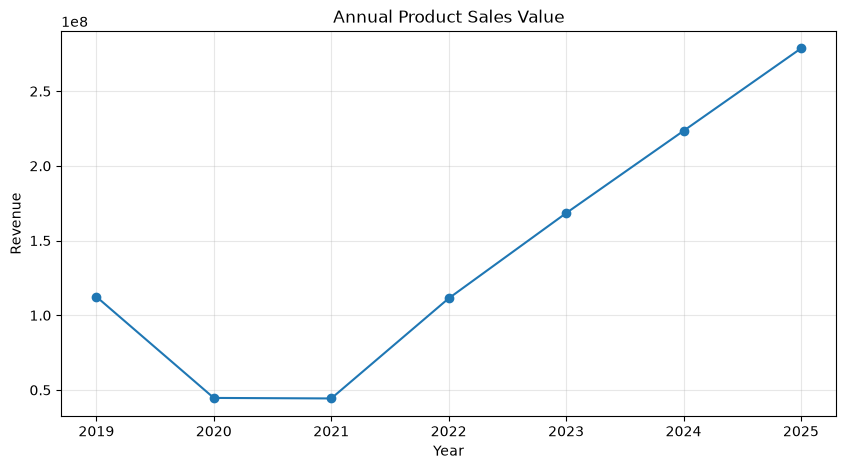

,category,revenue,gross_profit,units_sold,gross_margin_pct,profit_share_pct
2,electronics,7.327754e+08,1.333925e+08,690041,18.203736,53.039287
4,furniture,1.090914e+08,4.435314e+07,196837,40.656872,17.635618
3,fashion,6.782140e+07,4.236778e+07,474092,62.469637,16.846203
5,home_goods,3.388317e+07,1.668173e+07,315249,49.233067,6.632958
6,toys,1.258810e+07,6.959558e+06,248963,55.286795,2.767247
0,auto,2.122451e+07,5.449374e+06,78697,25.674914,2.166770
1,books,5.755156e+06,2.293448e+06,195940,39.850310,0.911917


In [20]:
# Calculate the core business KPIs from the validated analytical summary tables.
total_revenue = sales_performance["revenue"].sum()
total_orders = sales_performance["orders"].sum()
total_aov = total_revenue / total_orders
total_cost = product_economics["total_cost"].sum()
total_gross_profit = product_economics["gross_profit"].sum()
gross_margin = total_gross_profit / total_revenue

kpi_summary = pd.DataFrame({
    "KPI": [
        "Product Sales Value",
        "Orders",
        "Average Order Value",
        "Total Cost",
        "Gross Profit",
        "Gross Margin"
    ],
    "Value": [
        total_revenue,
        total_orders,
        total_aov,
        total_cost,
        total_gross_profit,
        gross_margin
    ]
})

kpi_summary


# Aggregate monthly sales performance to the annual level to identify long-term business trends.
annual_sales = (
    sales_performance
    .groupby("year", as_index=False)
    .agg(
        revenue=("revenue", "sum"),
        orders=("orders", "sum")
    )
)

# Calculate annual average order value from annual revenue and order volume.
annual_sales["aov"] = annual_sales["revenue"] / annual_sales["orders"]

# Calculate year-over-year revenue growth for trend analysis.
annual_sales["revenue_yoy_pct"] = annual_sales["revenue"].pct_change() * 100

annual_sales

# Visualize annual revenue to identify the overall growth pattern across the seven-year period.
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(
    annual_sales["year"],
    annual_sales["revenue"],
    marker="o"
)
plt.title("Annual Product Sales Value")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.xticks(annual_sales["year"])
plt.grid(True, alpha=0.3)
plt.show()

# Display annual revenue and year-over-year growth together for business performance interpretation.
annual_sales[["year", "revenue", "orders", "aov", "revenue_yoy_pct"]]

# Analyze revenue, order volume, and sales contribution by product category
category_analysis = category_performance.groupby("category", as_index=False).agg(
    revenue=("revenue", "sum"),
    orders=("orders", "sum"),
    units_sold=("units_sold", "sum")
)
# Calculate average order value for each product category
category_analysis["aov"] = category_analysis["revenue"] / category_analysis["orders"]
# Calculate each category's contribution to total product sales value
category_analysis["revenue_share_pct"] = category_analysis["revenue"] / total_revenue * 100
# Sort categories by revenue to identify the main revenue drivers
category_analysis = category_analysis.sort_values("revenue", ascending=False)
category_analysis

# Analyze revenue and profitability by product category
category_profitability = product_performance.groupby("category", as_index=False).agg(
    revenue=("revenue", "sum"),
    gross_profit=("gross_profit", "sum"),
    units_sold=("units_sold", "sum")
)
# Calculate gross margin for each product category
category_profitability["gross_margin_pct"] = (
    category_profitability["gross_profit"] / category_profitability["revenue"] * 100
)
# Calculate each category's contribution to total gross profit
category_profitability["profit_share_pct"] = (
    category_profitability["gross_profit"] / total_gross_profit * 100
)
# Sort categories by gross profit to identify the main profit contributors
category_profitability = category_profitability.sort_values("gross_profit", ascending=False)
category_profitability

In [22]:
# Identify the top products by revenue to measure product-level revenue concentration
top_products = product_economics.sort_values("revenue", ascending=False).copy()
# Calculate each product's contribution to total revenue
top_products["revenue_share_pct"] = top_products["revenue"] / total_revenue * 100
# Calculate cumulative revenue contribution for concentration analysis
top_products["cumulative_revenue_share_pct"] = top_products["revenue_share_pct"].cumsum()
# Display the top 20 products and their revenue contribution
top_products[[
    "product_id",
    "product_name",
    "category",
    "revenue",
    "gross_profit",
    "gross_margin_pct",
    "revenue_share_pct",
    "cumulative_revenue_share_pct"
]].head(20)

# Display the top 10 products with revenue and profitability metrics
top_10_products = top_products[[
    "product_id",
    "product_name",
    "category",
    "revenue",
    "gross_profit",
    "gross_margin_pct",
    "revenue_share_pct",
    "cumulative_revenue_share_pct"
]].head(10)
# Format financial metrics for easier interpretation
top_10_products["revenue"] = top_10_products["revenue"].round(2)
top_10_products["gross_profit"] = top_10_products["gross_profit"].round(2)
top_10_products["gross_margin_pct"] = top_10_products["gross_margin_pct"].round(2)
top_10_products["revenue_share_pct"] = top_10_products["revenue_share_pct"].round(2)
top_10_products["cumulative_revenue_share_pct"] = top_10_products["cumulative_revenue_share_pct"].round(2)
top_10_products

,product_id,product_name,category,revenue,gross_profit,gross_margin_pct,revenue_share_pct,cumulative_revenue_share_pct
962,83fbdf52-21a3-4b64-af45-76ff4437130b,Nimbus Headphones M767,electronics,4938901.80,1121617.14,0.23,0.50,0.50
1056,9086b2b2-6100-410b-9b9c-4db4109afcfa,Apex P960 Smartwatch,electronics,4894925.35,1153196.45,0.24,0.50,1.00
1590,d27b9b19-b9a9-4ea7-8f5a-253a977fdc4d,Nova Monitor A779,electronics,4893846.91,991567.82,0.20,0.50,1.50
887,7943b8ca-e76d-41b5-a01d-69e33614b774,Orion P631 Tablet,electronics,4877712.60,1173739.80,0.24,0.50,1.99
80,0be8ed49-fc0e-4841-b19f-a668ade1a1aa,Apex Headphones S938,electronics,4836486.72,1054306.63,0.22,0.49,2.49
1532,cbceed2a-2fef-4be6-9b8b-e6e3b03a6863,Nova M311 Tablet,electronics,4823852.34,875636.28,0.18,0.49,2.98
423,3952c856-34d0-435b-9ebc-4e05532cb5ac,Pulse X774 Smartwatch,electronics,4823155.26,668322.05,0.14,0.49,3.47
55,0726d086-56b4-4a93-8696-87ceee82dc51,Apex Tablet X807,electronics,4761642.85,1044473.27,0.22,0.48,3.95
1007,8a1b95bf-694e-44af-9ae4-af574fdcf0eb,Nova P896 Camera,electronics,4760142.66,1010785.23,0.21,0.48,4.44
1318,b19d2bb6-43a7-4ef8-9273-855ef5acf0dc,Nimbus A208 Camera,electronics,4758172.38,560948.82,0.12,0.48,4.92


In [23]:
# Measure product-level revenue concentration using Pareto thresholds
product_concentration = []
# Evaluate the revenue contribution of the top 1%, 5%, and 10% of products
for pct in [1, 5, 10]:
    n_products = max(1, round(len(top_products) * pct / 100))
    revenue_share = top_products.head(n_products)["revenue"].sum() / total_revenue * 100
    product_concentration.append({
        "top_product_pct": pct,
        "number_of_products": n_products,
        "revenue_share_pct": revenue_share
    })
# Convert the results into a DataFrame for reporting
product_concentration = pd.DataFrame(product_concentration)
product_concentration["revenue_share_pct"] = product_concentration["revenue_share_pct"].round(2)
product_concentration

,top_product_pct,number_of_products,revenue_share_pct
0,1,20,9.61
1,5,100,40.45
2,10,200,66.66
